# FISTA Reconstruction Example

This notebook demonstrates sparse reconstruction using FISTA (Fast Iterative Shrinkage-Thresholding Algorithm).

FISTA minimizes ChiSquared + L1 regularization to recover sparse Faraday depth spectra.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from csromer.pipelines.reconstruction import CSROMERReconstructorWrapper, make_fista_optimizer
from csromer.pipelines.simulation import ApplyNoiseStep, SimulateStep, run_simulation
from csromer.simulation import FaradayThinSource
from csromer.utils.array_utils import asnumpy

plt.rcParams['figure.figsize'] = (14, 8)
%matplotlib inline

## 1. Create Test Source

In [2]:
# Create source and run simulation pipeline
nu = np.linspace(1.0e9, 1.5e9, 128)
source = FaradayThinSource(
    nu=nu,
    s_nu=0.1,
    phi_gal=50.0,
    spectral_idx=-0.7,
)
run_simulation(
    source, [
        SimulateStep(),
        ApplyNoiseStep(0.01, random_state=np.random.RandomState(42)),
    ]
)

print(f"Source:")
print(f"  True RM: {source.phi_gal:.2f} rad/m²")
print(f"  Flux: {source.s_nu:.3f} Jy")

Source:
  True RM: 50.00 rad/m²
  Flux: 0.100 Jy


## 2. Run FISTA Reconstruction

In [3]:
# Create FISTA reconstructor (MFISTA = monotone FISTA for stable descent)
source.l2_ref = source.calculate_l2ref()
recon = CSROMERReconstructorWrapper(
    dataset=source,
    oversampling=7.0,
    measurement_operator_kind="gridded",
    optimizer_factory=make_fista_optimizer(
        maxiter=5000,
        tol=1e-12,
        verbose=True,
        monotonic=True,  # MFISTA: reject steps that increase the objective
    ),
    lambda_l_norm=0.8,
)

# Run reconstruction
recon.reconstruct()

print(f"\nReconstruction Results:")
print(f"  Dirty RM: {recon.rm_dirty:.2f} rad/m²")
print(f"  Model RM: {recon.rm_model:.2f} rad/m²")
print(f"  Restored RM: {recon.rm_restored:.2f} rad/m²")
print(f"  True RM: {source.phi_gal:.2f} rad/m²")

FWHM of the main peak of the RMTF: 69.378 rad/m^2
Maximum recovered width structure: 78.649 rad/m^2
Maximum Faraday Depth to which one has more than 50% sensitivity: 4405.503
FISTA step: backtracking (FISTABacktracking)
Initial function value = 299.004570
Iteration: 10  objective: 6.67018
Iteration: 20  objective: 6.50762
Iteration: 30  objective: 6.47394
Iteration: 40  objective: 6.46148
Iteration: 50  objective: 6.45550
Iteration: 60  objective: 6.45217
Iteration: 70  objective: 6.45013
Iteration: 80  objective: 6.44878
Iteration: 90  objective: 6.44787
Iteration: 100  objective: 6.44718
Iteration: 110  objective: 6.44666
Iteration: 120  objective: 6.44627
Iteration: 130  objective: 6.44591
Iteration: 140  objective: 6.44550
Iteration: 150  objective: 6.44507
Iteration: 160  objective: 6.44461
Iteration: 170  objective: 6.44413
Iteration: 180  objective: 6.44364
Iteration: 190  objective: 6.44313
Iteration: 200  objective: 6.44262
Iteration: 210  objective: 6.44209
Iteration: 220  ob

## 3. Visualize Results

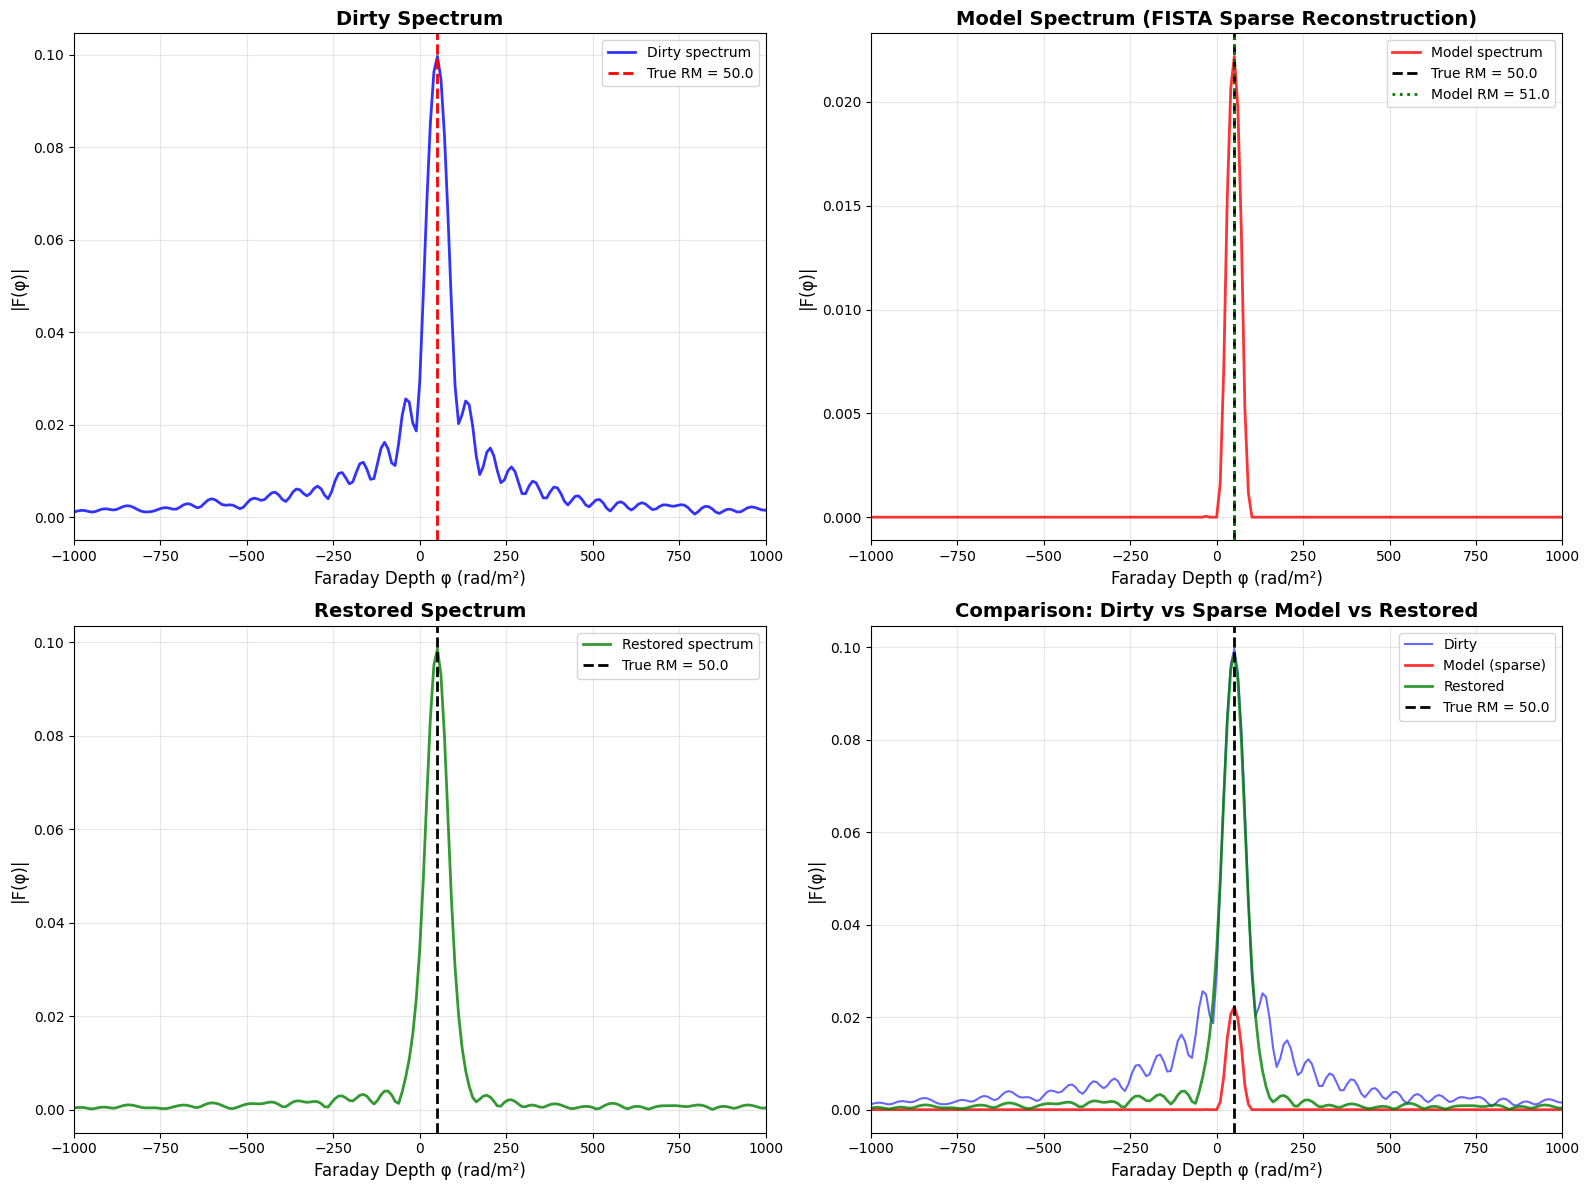


FISTA Reconstruction:
The model spectrum shows sparse reconstruction with L1 regularization.
This suppresses sidelobes and noise while preserving the main signal.


In [4]:
phi = np.asarray(asnumpy(recon.parameter.phi))
fd_dirty = np.asarray(asnumpy(recon.fd_dirty))
fd_model = np.asarray(asnumpy(recon.fd_model))
fd_restored = np.asarray(asnumpy(recon.fd_restored_abs))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Dirty spectrum
ax = axes[0, 0]
ax.plot(phi, np.abs(fd_dirty), 'b-', linewidth=2, label='Dirty spectrum', alpha=0.8)
ax.axvline(
    source.phi_gal, color='r', linestyle='--', linewidth=2, label=f'True RM = {source.phi_gal:.1f}'
)
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)
ax.set_ylabel('|F(φ)|', fontsize=12)
ax.set_title('Dirty Spectrum', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-1000, 1000)

# Plot 2: Model spectrum (sparse reconstruction)
ax = axes[0, 1]
ax.plot(phi, np.abs(fd_model), 'r-', linewidth=2, label='Model spectrum', alpha=0.8)
ax.axvline(
    source.phi_gal, color='k', linestyle='--', linewidth=2, label=f'True RM = {source.phi_gal:.1f}'
)
ax.axvline(
    recon.rm_model, color='g', linestyle=':', linewidth=2, label=f'Model RM = {recon.rm_model:.1f}'
)
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)
ax.set_ylabel('|F(φ)|', fontsize=12)
ax.set_title('Model Spectrum (FISTA Sparse Reconstruction)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-1000, 1000)

# Plot 3: Restored spectrum
ax = axes[1, 0]
ax.plot(phi, fd_restored, 'g-', linewidth=2, label='Restored spectrum', alpha=0.8)
ax.axvline(
    source.phi_gal, color='k', linestyle='--', linewidth=2, label=f'True RM = {source.phi_gal:.1f}'
)
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)
ax.set_ylabel('|F(φ)|', fontsize=12)
ax.set_title('Restored Spectrum', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-1000, 1000)

# Plot 4: Comparison
ax = axes[1, 1]
ax.plot(phi, np.abs(fd_dirty), 'b-', linewidth=1.5, label='Dirty', alpha=0.6)
ax.plot(phi, np.abs(fd_model), 'r-', linewidth=2, label='Model (sparse)', alpha=0.8)
ax.plot(phi, fd_restored, 'g-', linewidth=2, label='Restored', alpha=0.8)
ax.axvline(
    source.phi_gal, color='k', linestyle='--', linewidth=2, label=f'True RM = {source.phi_gal:.1f}'
)
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)
ax.set_ylabel('|F(φ)|', fontsize=12)
ax.set_title('Comparison: Dirty vs Sparse Model vs Restored', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-1000, 1000)

plt.tight_layout()
plt.show()

print("\nFISTA Reconstruction:")
print("The model spectrum shows sparse reconstruction with L1 regularization.")
print("This suppresses sidelobes and noise while preserving the main signal.")

## 4. Sparsity Analysis

Sparsity Analysis:
  Dirty spectrum: 39 significant points (>10% of peak)
  Model spectrum: 7 significant points (>10% of peak)
  Sparsity improvement: 5.6x


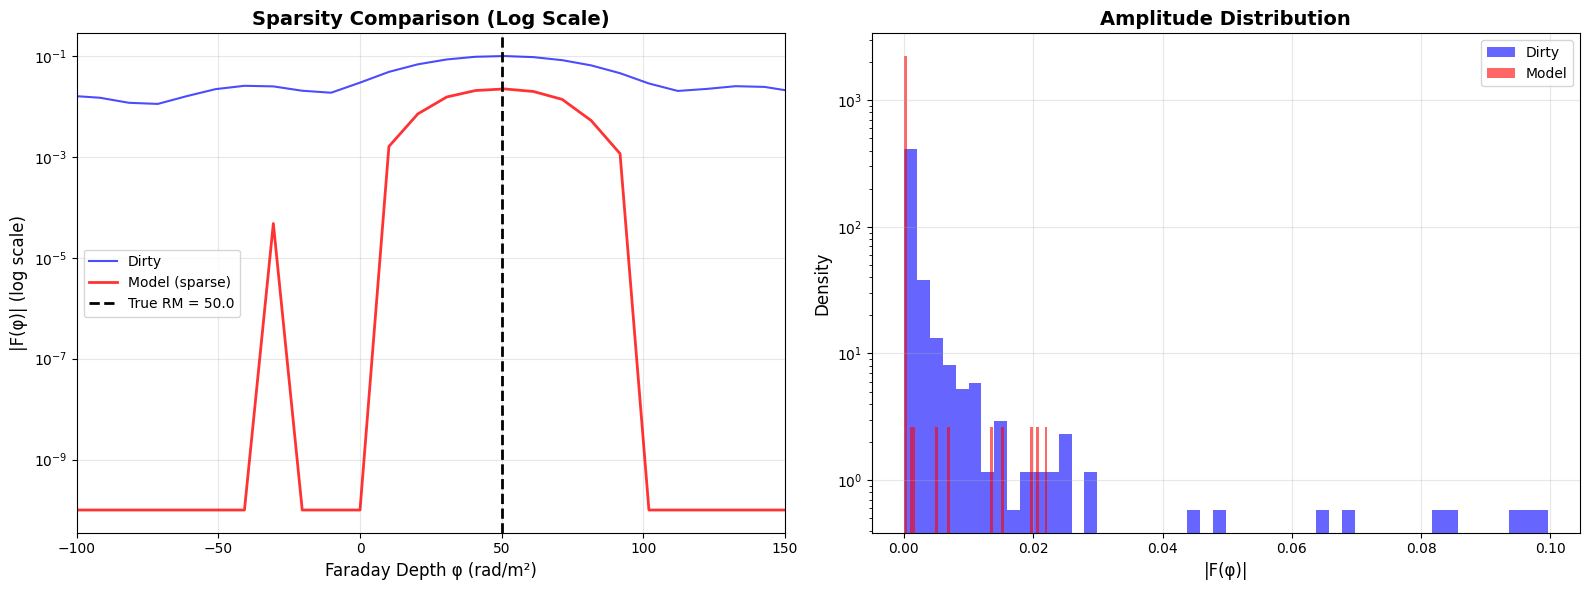

In [5]:
# Analyze sparsity
dirty_nonzero = np.sum(np.abs(fd_dirty) > np.max(np.abs(fd_dirty)) * 0.1)
model_nonzero = np.sum(np.abs(fd_model) > np.max(np.abs(fd_model)) * 0.1)

print("Sparsity Analysis:")
print(f"  Dirty spectrum: {dirty_nonzero} significant points (>10% of peak)")
print(f"  Model spectrum: {model_nonzero} significant points (>10% of peak)")
print(f"  Sparsity improvement: {dirty_nonzero / max(model_nonzero, 1):.1f}x")

# Plot sparsity comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Log scale comparison
ax = axes[0]
ax.semilogy(phi, np.abs(fd_dirty) + 1e-10, 'b-', linewidth=1.5, label='Dirty', alpha=0.7)
ax.semilogy(phi, np.abs(fd_model) + 1e-10, 'r-', linewidth=2, label='Model (sparse)', alpha=0.8)
ax.axvline(
    source.phi_gal, color='k', linestyle='--', linewidth=2, label=f'True RM = {source.phi_gal:.1f}'
)
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)
ax.set_ylabel('|F(φ)| (log scale)', fontsize=12)
ax.set_title('Sparsity Comparison (Log Scale)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')
ax.set_xlim(-100, 150)

# Histogram of amplitudes
ax = axes[1]
ax.hist(np.abs(fd_dirty), bins=50, alpha=0.6, label='Dirty', color='b', density=True)
ax.hist(np.abs(fd_model), bins=50, alpha=0.6, label='Model', color='r', density=True)
ax.set_xlabel('|F(φ)|', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Amplitude Distribution', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()